
# MFML Cross-Validation and Learning Curves

As we saw in on of the previous examples, learning curves are a
vital metric for evaluating kernel-based machine learning
methods. They depict the relationship between the model's prediction error and
the amount of training data provided.

However, validating a Multi-Fidelity Machine Learning (MFML) model requires a
highly specialized approach due to the strict structural constraints of the data.


## The Nested Cross-Validation Strategy
Due to the strictly nested structure of the training data used in MFML,
conventional cross-validation methods (like standard K-Fold random shuffling)
**cannot be used**. If we were to randomly shuffle the training sets for each
fidelity independently, we would break the hierarchy guarantee—meaning a high-fidelity
geometry might no longer exist in the baseline training set!

To ensure our results are robust to the choice of training data while preserving
this nested structure, we must use a **Nested Validation** algorithm.

For each random shuffle iteration, the procedure is as follows:

1. **Highest Fidelity Sampling**: Randomly select a target number of training samples,
   $N_{\rm train}^{F}$, from the available highest fidelity dataset. This forms
   the apex subset, $\mathcal{G}^{F}$.
2. **Upper and Lower Sub-models**: Train the highest fidelity sub-model on this set.
   Crucially, extract the exact same geometries at the *lower* fidelity, $F-1$,
   to train the corresponding lower sub-model.
3. **Going Downwards**: At the next lower fidelity ($f = F-1$), build the
   new training set by strictly inheriting the geometries selected in step 1, and
   then randomly sampling the remaining required geometries from the available pool:

\begin{align}\mathcal{G}^{F-1} := \mathcal{G}^{F}_{\mathrm{inherited}} \cup \mathcal{G}^{F-1}_{\mathrm{random}}\end{align}

4. **Recursion**: Repeat this nested sampling process recursively downwards until
   the baseline fidelity ($f = f_b$) is reached.

More details can be found in the publication:
Mach. Learn.: Sci. Technol. 5 015054 (10.1088/2632-2153/ad2cef)

Finally, all models are evaluated on an unseen test set, and the prediction errors
are reported as Mean Absolute Errors (MAE) using a discrete $L_1$ norm:

\begin{align}MAE = \frac{1}{N_{\mathrm{test}}}\sum_{q=1}^{N_{\mathrm{test}}}\left\lvert P_{\mathrm{ML}}\left(\boldsymbol{X}_q^{\mathrm{ref}}\right) - {y}^{\mathrm{ref}}_q\right\rvert\end{align}

Fortunately, the ``ModelMFML`` class natively handles this entire complex
algorithm internally!



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from mfml_qc.datasets import load_benzene_data
from mfml_qc.utils import build_hierarchy_arrays, top_down_subsetting
from mfml_qc.mfml import ModelMFML

/home/vvinod/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading and Formatting Data
We load the dataset and establish our fixed test set of the last 2,712 geometries.
The remaining 12,288 geometries act as our sampling pool.



In [2]:
dataset = load_benzene_data()

X_CM = dataset["X_CM"]
data = dataset["energies"]

# Fidelities: LC-DFTB, STO-3G, def2-SVP, def2-TZVP
hierarchy_cols = [2, 3, 6, 7]

# Establish fixed train/test masks
train_mask = data[:, 0] < 12288
test_mask = data[:, 0] >= 12288

X_train_parent = X_CM[train_mask]
X_test = X_CM[test_mask]
data_train = data[train_mask]
data_test = data[test_mask]

y_trains, indexes, means = build_hierarchy_arrays(data_train, hierarchy_cols)

# Extract test (reference) energies
y_test_true = data_test[:, hierarchy_cols[-1]]

## Generating the Learning Curve
We will generate a learning curve by training the MFML model at different
training set sizes. To ensure the nested hierarchy is maintained, we simply
double the training size at each lower fidelity (e.g., if the highest fidelity
gets 64 samples, the hierarchy will be 512, 256, 128, 64).

We perform this for ``navg = 5`` random shuffles to calculate variance.
*(Note: For production publication, navg=10 or higher is recommended).*



In [3]:
# High fidelity target sizes
hf_train_sizes = 2 ** np.arange(1, 9)
navg = 5

# Storage array for MAEs: shape (num_sizes, navg)
mfml_maes = np.zeros((len(hf_train_sizes), navg))

# Initialize a base model once
mfml_model = ModelMFML(kernel="matern", sigma=715.0, reg=1e-9, p_bar=False)

for n in range(navg):
    for s_idx, hf_size in enumerate(hf_train_sizes):
        # Define the target hierarchy sizes: [8x, 4x, 2x, 1x]
        n_trains_target = [hf_size * 8, hf_size * 4, hf_size * 2, hf_size]
        # Nested shuffling of data
        subset_y_trains, subset_indexes = top_down_subsetting(
            y_trains, indexes, n_trains_target, seed=42 + n
        )
        # Train the MFML model
        mfml_model.train(
            X_train_parent=X_train_parent,
            y_trains=subset_y_trains,
            indexes=subset_indexes,
        )
        # Predict on the test set
        preds = mfml_model.predict(X_test=X_test, optimiser="default")
        preds += means[-1]  # Un-center predictions

        # MAE in kcal/mol
        mae = np.mean(np.abs(preds - y_test_true)) * 23

        mfml_maes[s_idx, n] = mae

Extracting X_trains:   0%|                                                                                                         | 0/4 [00:00<?, ?it/s]

Extracting upper y_trains:   0%|                                                                                                   | 0/4 [00:00<?, ?it/s]

Extracting lower y_trains:   0%|                                                                                                   | 0/3 [00:00<?, ?it/s]

Training upper ML models...:   0%|                                                                                                 | 0/4 [00:00<?, ?it/s]

Training upper ML models...:  25%|██████████████████████▎                                                                  | 1/4 [00:02<00:07,  2.65s/it]

...

Upper MFML predictions:  75%|██████████████████████████████████████████████████████████████████████▌                       | 3/4 [00:00<00:00,  4.91it/s]

Lower MFML predictions:   0%|                                                                                                      | 0/3 [00:00<?, ?it/s]

Lower MFML predictions:  33%|███████████████████████████████▎                                                              | 1/3 [00:00<00:00,  4.47it/s]

Lower MFML predictions:  67%|██████████████████████████████████████████████████████████████▋                               | 2/3 [00:00<00:00,  5.53it/s]

Lower MFML predictions: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  6.82it/s]

## Visualizing the Learning Curve
Finally, we can plot the average MAE with standard deviation error bars
against the number of high-fidelity training samples.



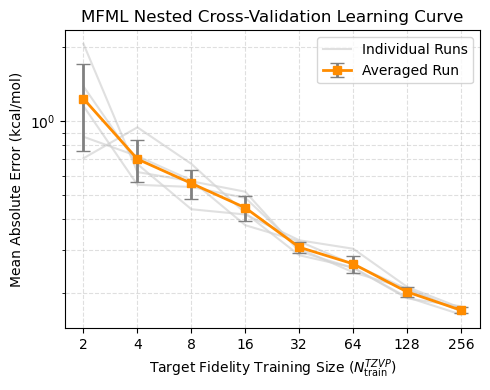

In [4]:
mean_mae = np.mean(mfml_maes, axis=1)
std_mae = np.std(mfml_maes, axis=1)

plt.figure(figsize=(5, 4))

# individual learning curves
for n in range(navg):
    plt.plot(
        hf_train_sizes,
        mfml_maes[:, n],
        color="lightgray",
        linestyle="-",
        alpha=0.7,
        zorder=1,
        label="Individual Runs" if n == 0 else None,
    )

# the average learning curve
plt.errorbar(
    hf_train_sizes,
    mean_mae,
    yerr=std_mae,
    fmt="s-",
    color="darkorange",
    ecolor="gray",
    capsize=5,
    linewidth=2,
    label="Averaged Run",
)

# plot cosmetics
plt.xscale("log", base=2)
plt.yscale("log")
plt.xticks(hf_train_sizes, labels=[str(s) for s in hf_train_sizes])

plt.xlabel(r"Target Fidelity Training Size ($N_{\rm train}^{TZVP}$)")
plt.ylabel("Mean Absolute Error (kcal/mol)")
plt.title("MFML Nested Cross-Validation Learning Curve")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Comparing to Single-Fidelity
In a typical research workflow, you would plot this curve alongside a standard
single-fidelity learning curve (like the one generated in Tutorial 2) to
explicitly demonstrate the data-efficiency gains achieved by leveraging
lower-level baseline calculations!

